In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv('UofU 650-05-546 BHA 38 - output data.csv', skiprows=35)
torsionalCol = "Bit Box_ShYrms(g)"
lateralCol = "Bit Box_ShZrms(g)"
axialCol = "Bit Box_ShXrms(g)"


Missing values per column:
 Bit Box_GyroXmax(RPM)                                    2045
Bit Box_GyroXmed(RPM)                                    2045
Bit Box_Temperature(C)                                   2045
Bit Box_ShXpeak(g)                                       2045
Bit Box_ShXrms(g)                                        2045
Bit Box_ShXmax(g)                                        2045
Bit Box_ShYpeak(g)                                       2045
Bit Box_ShYrms(g)                                        2045
Bit Box_ShYmax(g)                                        2045
Bit Box_ShZpeak(g)                                       2045
Bit Box_ShZrms(g)                                        2045
Bit Box_ShZmax(g)                                        2045
Top Sub_GyroXmax(RPM)                                    2331
Top Sub_GyroXmed(RPM)                                    2331
Top Sub_GyroXmin(RPM)                                    2331
Top Sub_StickSlip(%)                      

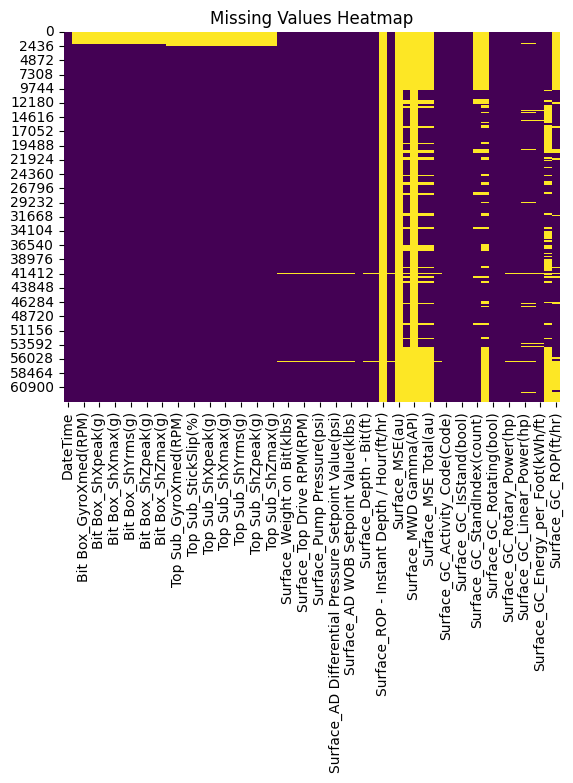

In [20]:
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
data["Augmented RPM(RPM)"] = np.where(
    data["Surface_GC_Rotating(bool)"] == 1,
    data["Surface_Flow In(GPM)"] * 0.242 + data["Surface_Top Drive RPM(RPM)"],
    data["Surface_Flow In(GPM)"] * 0.242
)
data = data[(data["Augmented RPM(RPM)"] < 230) & (data["Augmented RPM(RPM)"] > 10)]

10.00330474 229.99913012


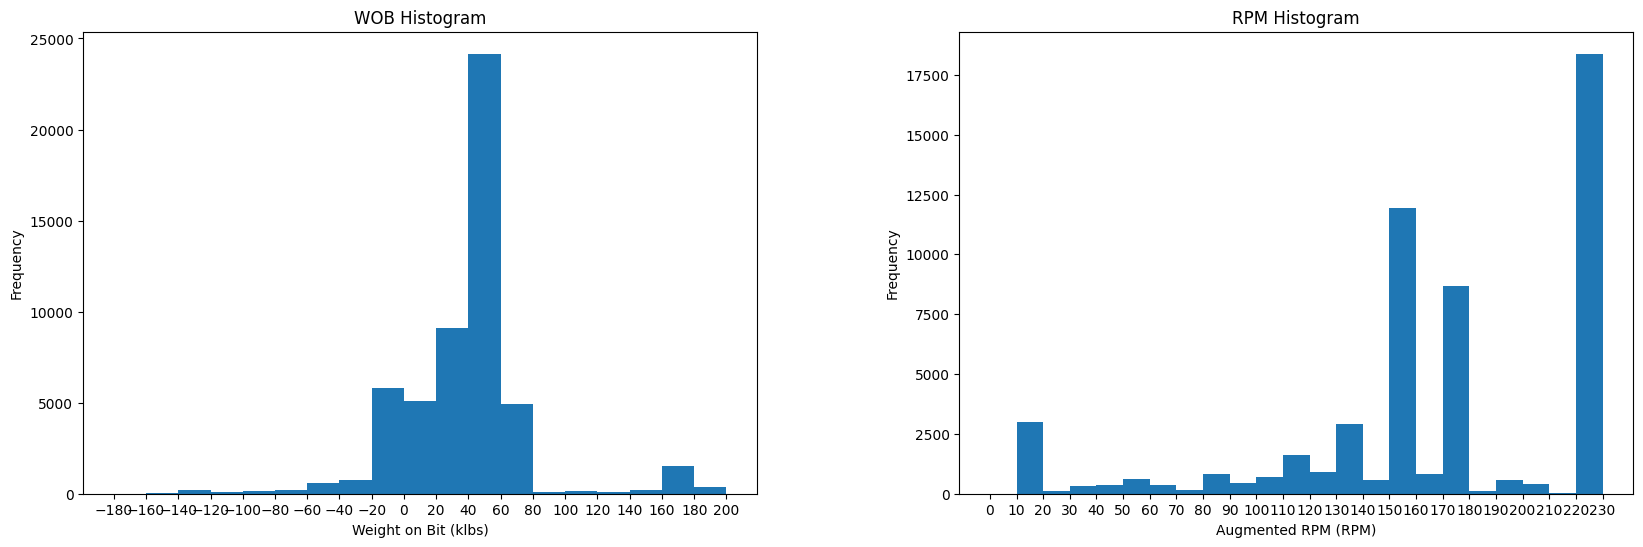

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Create figure with ONLY 2 subplots
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

# --------------------------------------------------
# WOB Histogram
# --------------------------------------------------
WOB = data["Surface_Weight on Bit(klbs)"].dropna()

min_wob = WOB.min()
max_wob = WOB.max()
binsWOB = np.arange(-180, max_wob + 20, 20)

axes[0].hist(WOB, bins=binsWOB)
axes[0].set_xlabel("Weight on Bit (klbs)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("WOB Histogram")
axes[0].set_xticks(binsWOB)

# --------------------------------------------------
# RPM Histogram
# --------------------------------------------------
RPM = data["Augmented RPM(RPM)"].dropna()

min_RPM = RPM.min()
max_RPM = RPM.max()
print(min_RPM, max_RPM)
binsRPM = np.arange(0, max_RPM + 10, 10)

axes[1].hist(RPM, bins=binsRPM)
axes[1].set_xlabel("Augmented RPM (RPM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("RPM Histogram")
axes[1].set_xticks(binsRPM)

plt.show()



In [23]:
data = data[(data["Surface_Weight on Bit(klbs)"] >= 10) & (data["Surface_Weight on Bit(klbs)"] <= 100)]
data = data.dropna(subset=[torsionalCol])


dataDrilling = data[data["Surface_GC_OnBottom(bool)"] == 1]
dataNotDrilling = data[data["Surface_GC_OnBottom(bool)"] == 0]
dataNotDrilling["Surface_Weight on Bit(klbs)"] = 0
dataRotating = dataDrilling[dataDrilling["Surface_GC_Rotating(bool)"] == 1]
dataSliding = dataDrilling[dataDrilling["Surface_GC_Sliding(bool)"] == 1]

C:\Users\Isaac Xu\AppData\Local\Temp\ipykernel_24624\1378756124.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataNotDrilling["Surface_Weight on Bit(klbs)"] = 0


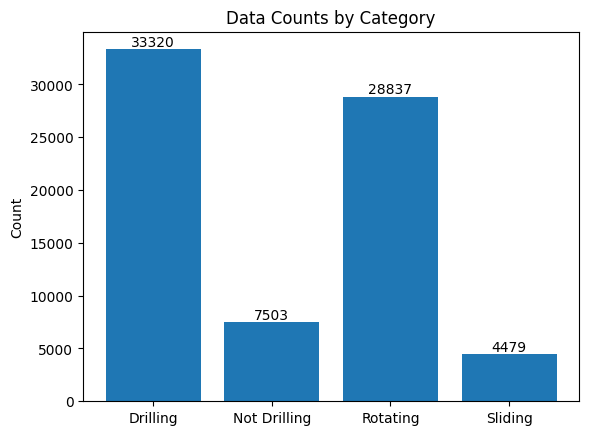

In [24]:
dataSizes = np.array([
    len(dataDrilling),
    len(dataNotDrilling),
    len(dataRotating),
    len(dataSliding)
])

labels = ["Drilling", "Not Drilling", "Rotating", "Sliding"]

plt.bar(labels, dataSizes)

# Add labels above bars
for i, v in enumerate(dataSizes):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.ylabel("Count")
plt.title("Data Counts by Category")
plt.show()


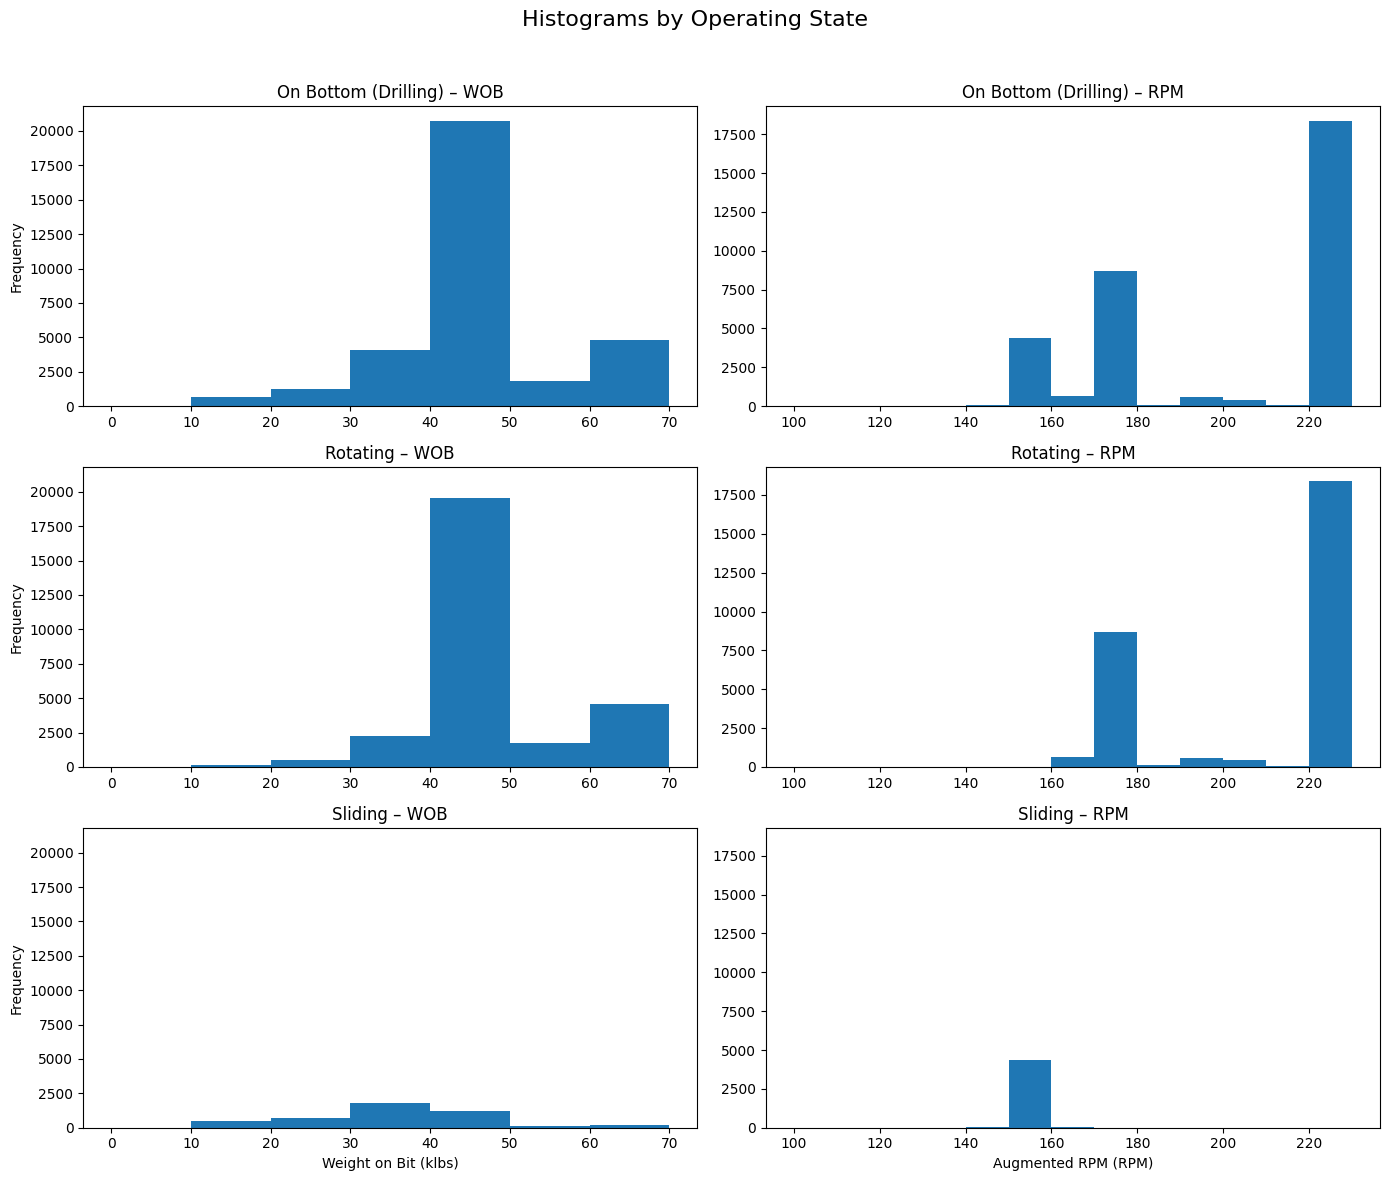

In [25]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=3, ncols=2,
    figsize=(14, 12),
    sharex='col',
    sharey='col'
)

plt.subplots_adjust(hspace=0.35)

datasets = [
    ("On Bottom (Drilling)", dataDrilling),
    ("Rotating", dataRotating),
    ("Sliding", dataSliding),
]

for row, (title, df) in enumerate(datasets):

    # WOB
    WOB = df["Surface_Weight on Bit(klbs)"].dropna()
    bins_wob = np.arange(0, WOB.max() + 10, 10)

    axes[row, 0].hist(WOB, bins=bins_wob)
    axes[row, 0].set_title(f"{title} – WOB")
    axes[row, 0].set_ylabel("Frequency")

    # RPM
    RPM = df["Augmented RPM(RPM)"].dropna()
    bins_rpm = np.arange(100, RPM.max() + 10, 10)

    axes[row, 1].hist(RPM, bins=bins_rpm)
    axes[row, 1].set_title(f"{title} – RPM")

# Axis labels
axes[-1, 0].set_xlabel("Weight on Bit (klbs)")
axes[-1, 1].set_xlabel("Augmented RPM (RPM)")

# 🔹 Force x-ticks on every subplot
for ax in axes.flat:
    ax.tick_params(labelbottom=True)

fig.suptitle("Histograms by Operating State", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [26]:
dataDrilling = dataDrilling[dataDrilling["Surface_Weight on Bit(klbs)"] >= 10]
dataRotating = dataRotating[dataRotating["Surface_Weight on Bit(klbs)"] >= 10]
dataSliding = dataSliding[dataSliding["Surface_Weight on Bit(klbs)"] >= 10]

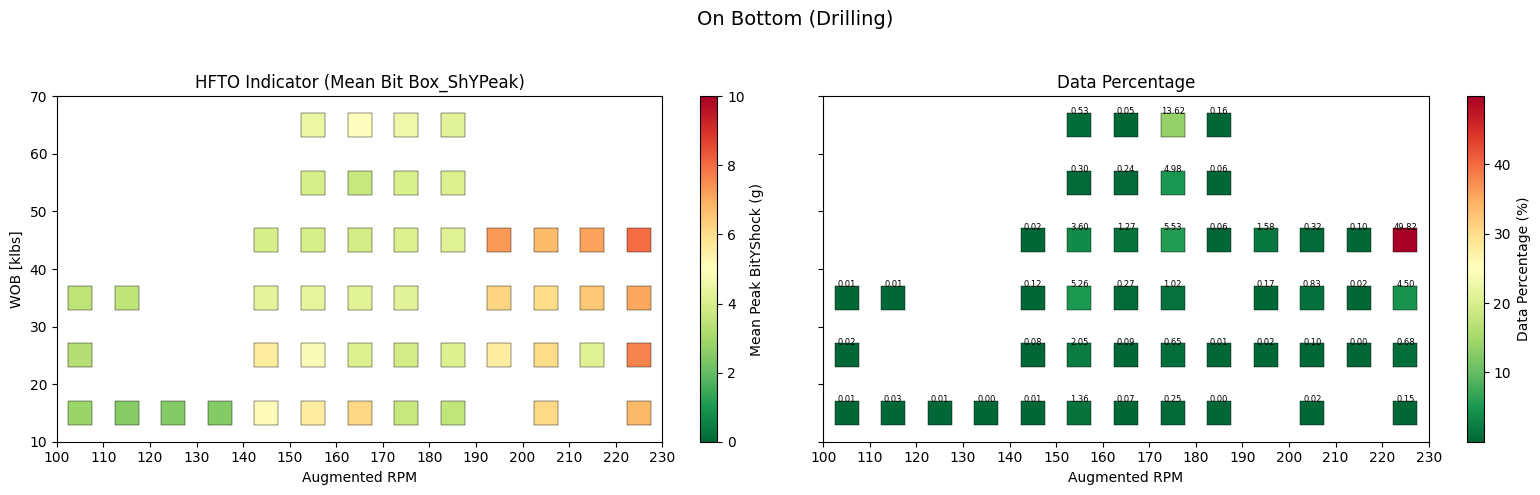

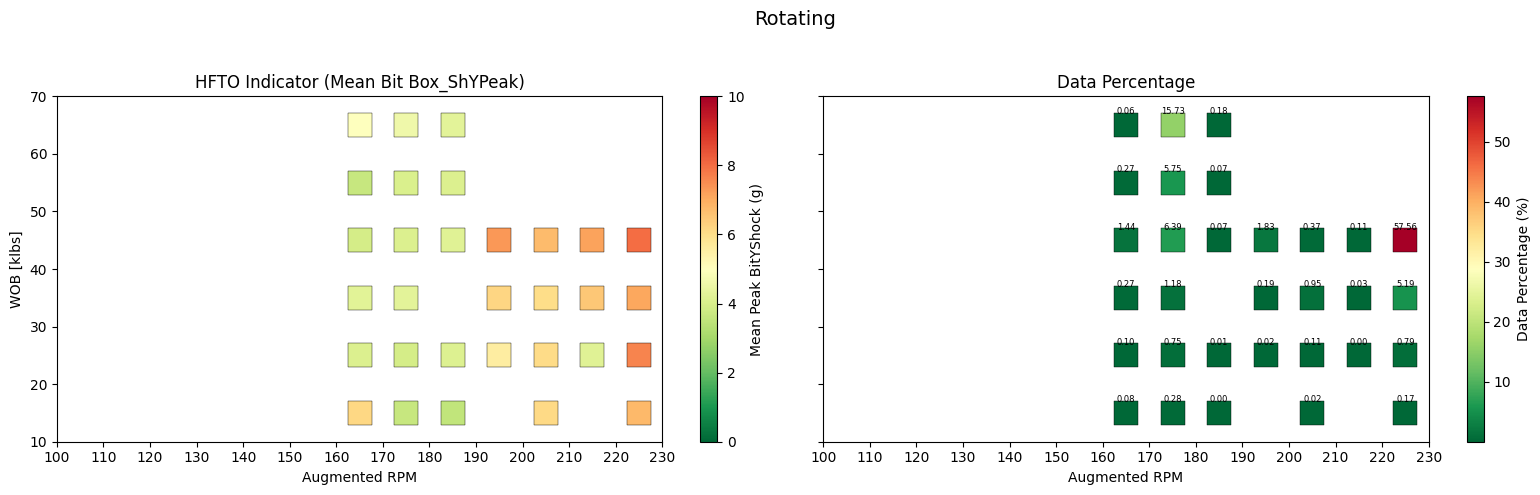

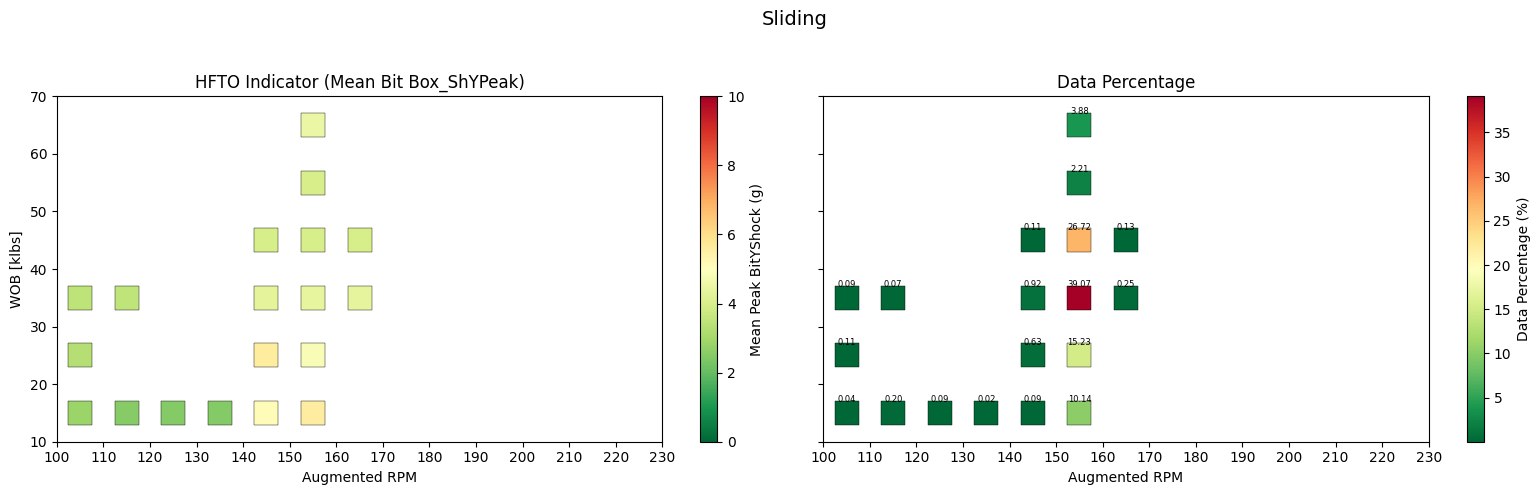

In [34]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}

selected_states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = torsionalCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in selected_states.values())
maxrpm_raw = max(df[rpm_col].max() for df in selected_states.values())

minwob_raw = min(df[wob_col].min() for df in selected_states.values())
maxwob_raw = max(df[wob_col].max() for df in selected_states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 10

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShYPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitYShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)


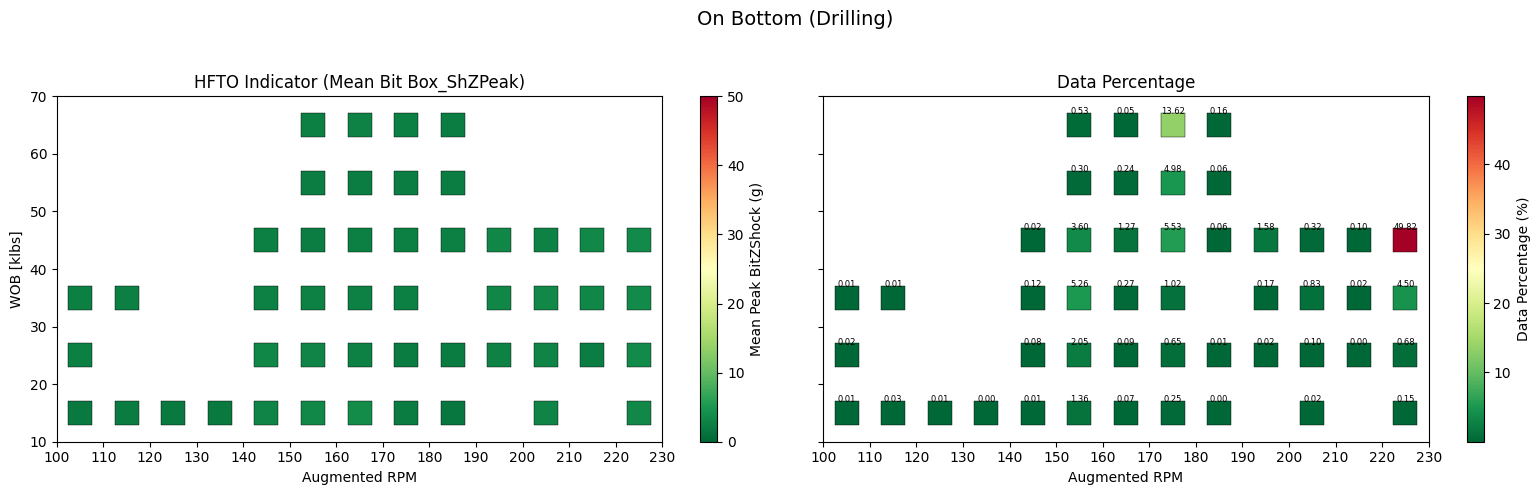

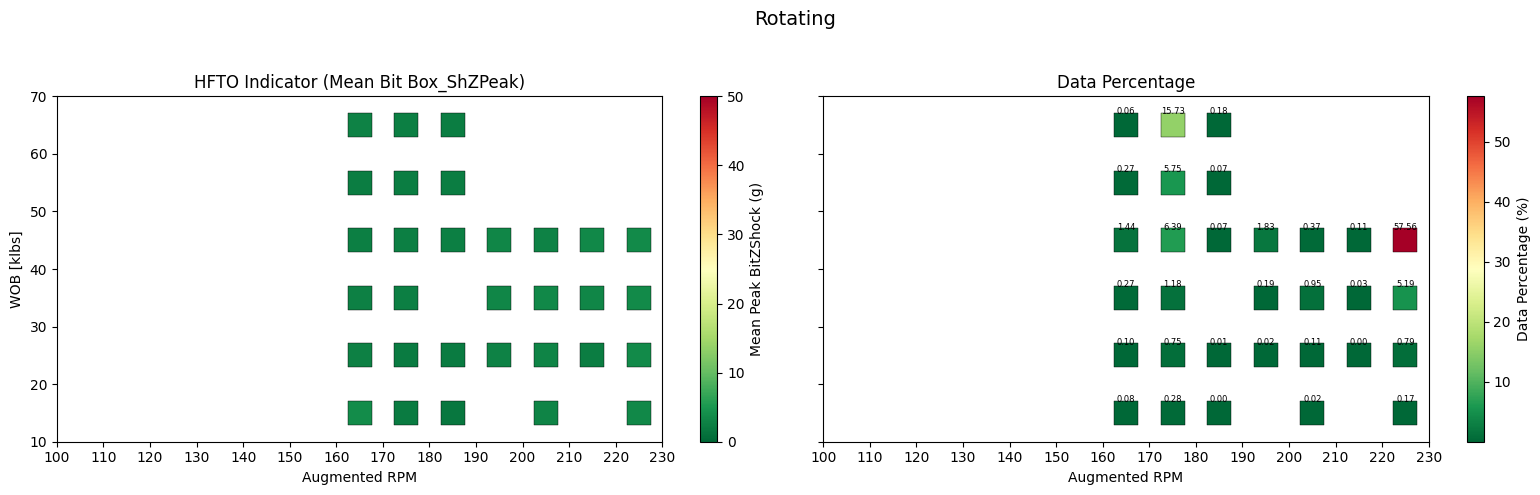

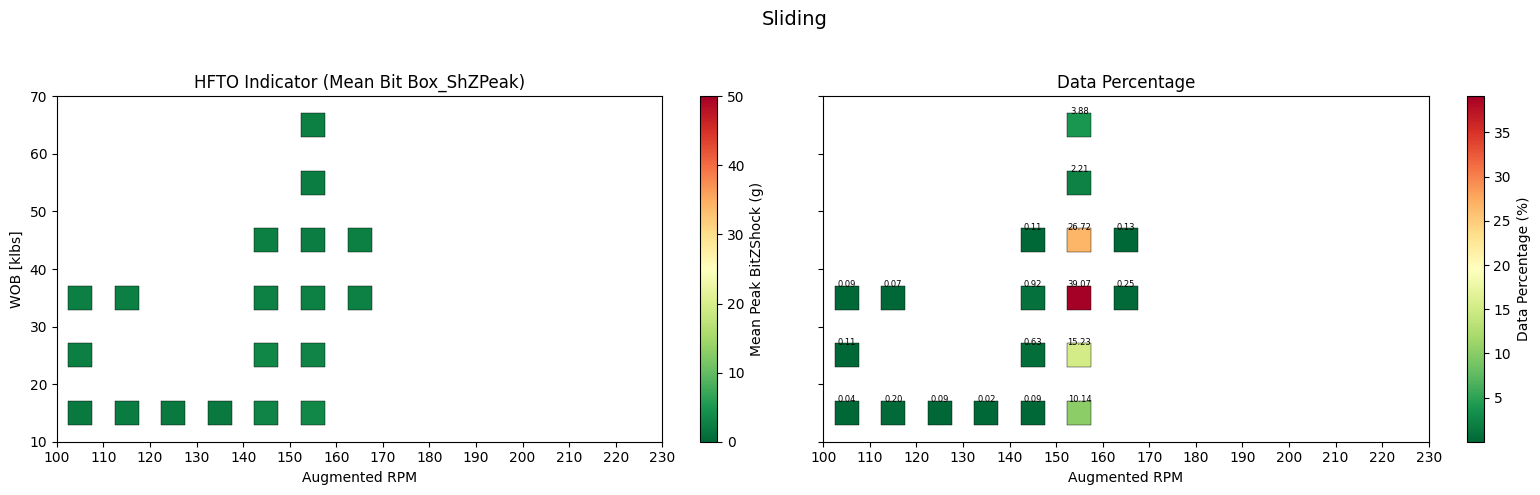

In [28]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}

selected_states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = lateralCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in selected_states.values())
maxrpm_raw = max(df[rpm_col].max() for df in selected_states.values())

minwob_raw = min(df[wob_col].min() for df in selected_states.values())
maxwob_raw = max(df[wob_col].max() for df in selected_states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShZPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitZShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

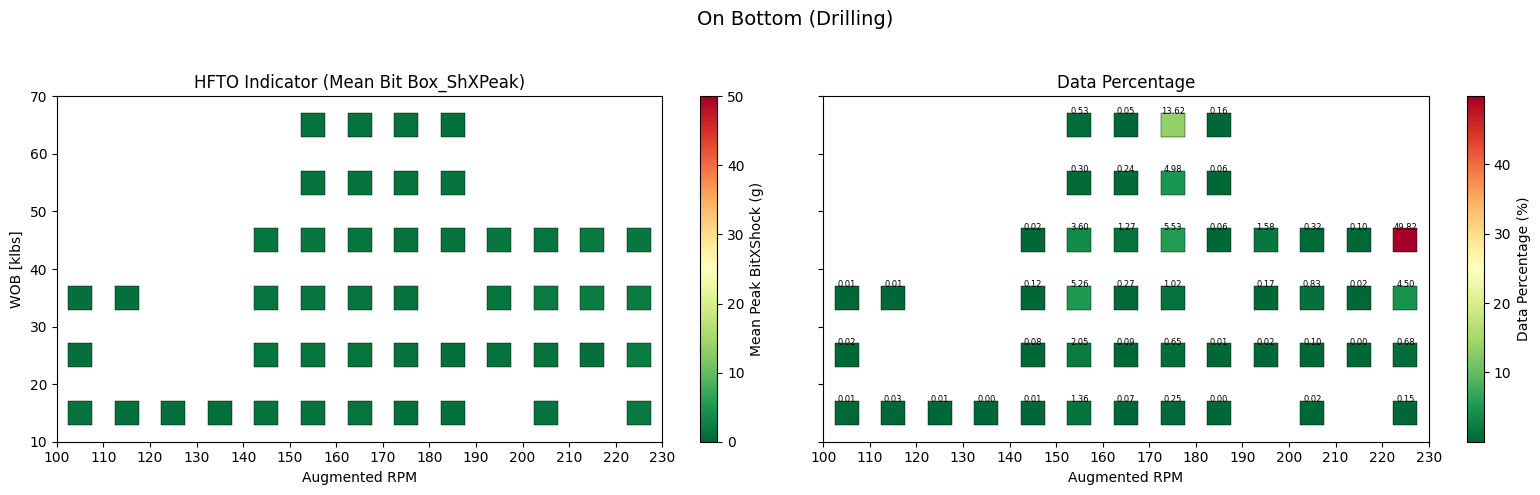

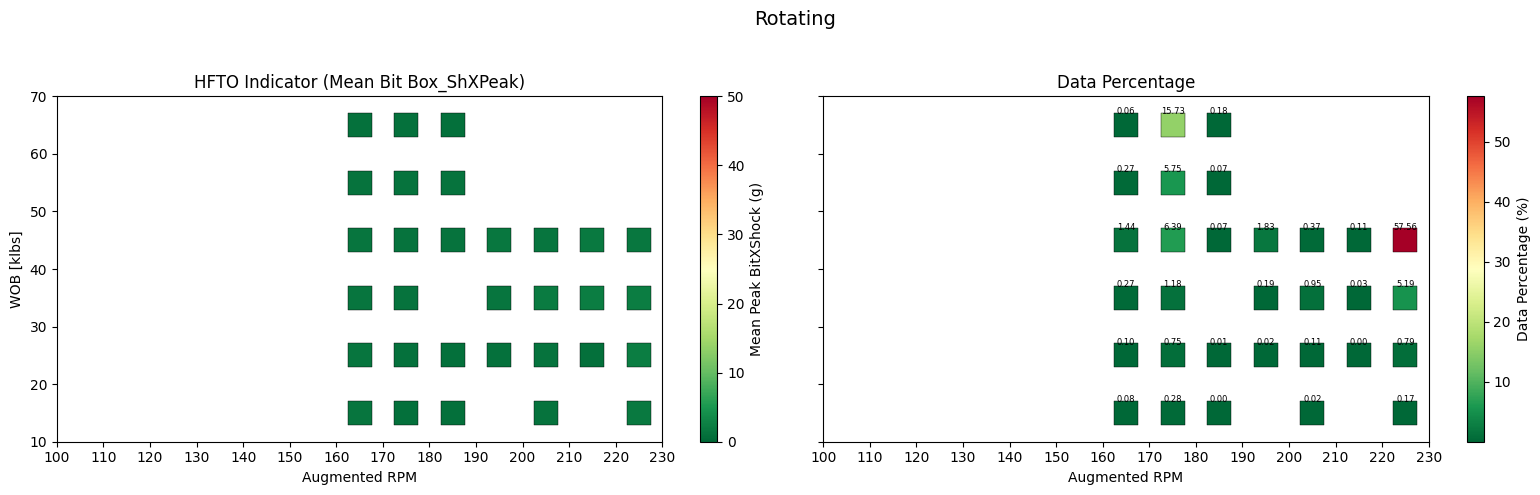

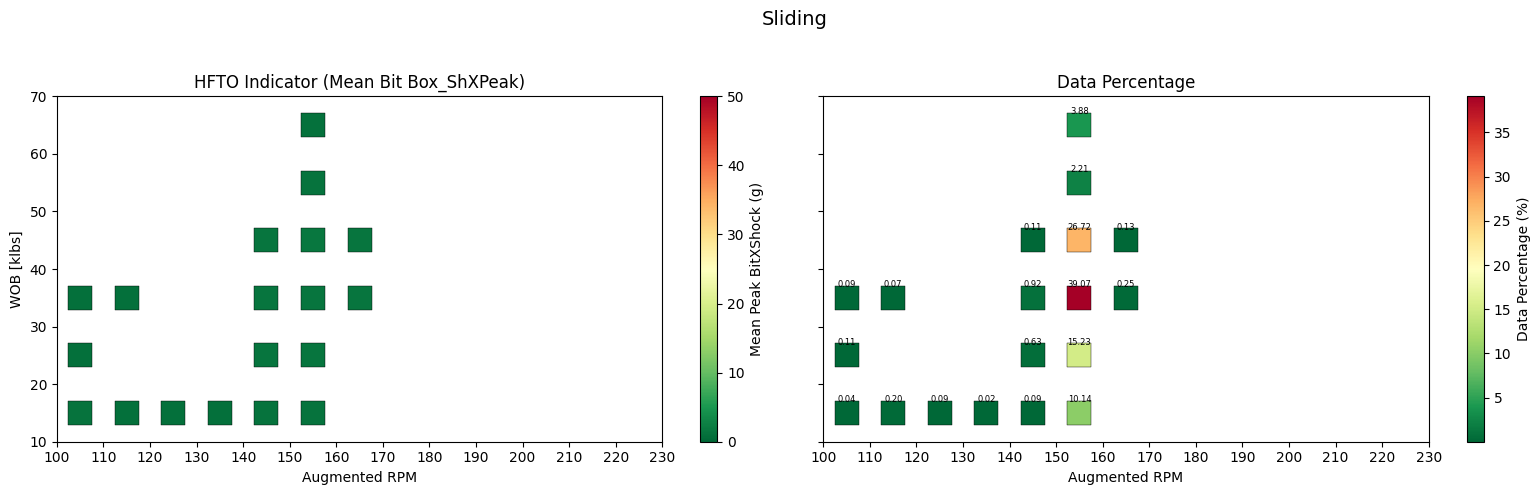

In [29]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}

selected_states = {
    "On Bottom (Drilling)": dataDrilling,
    "Rotating": dataRotating,
    "Sliding": dataSliding
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = axialCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in selected_states.values())
maxrpm_raw = max(df[rpm_col].max() for df in selected_states.values())

minwob_raw = min(df[wob_col].min() for df in selected_states.values())
maxwob_raw = max(df[wob_col].max() for df in selected_states.values())

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShXPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitXShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

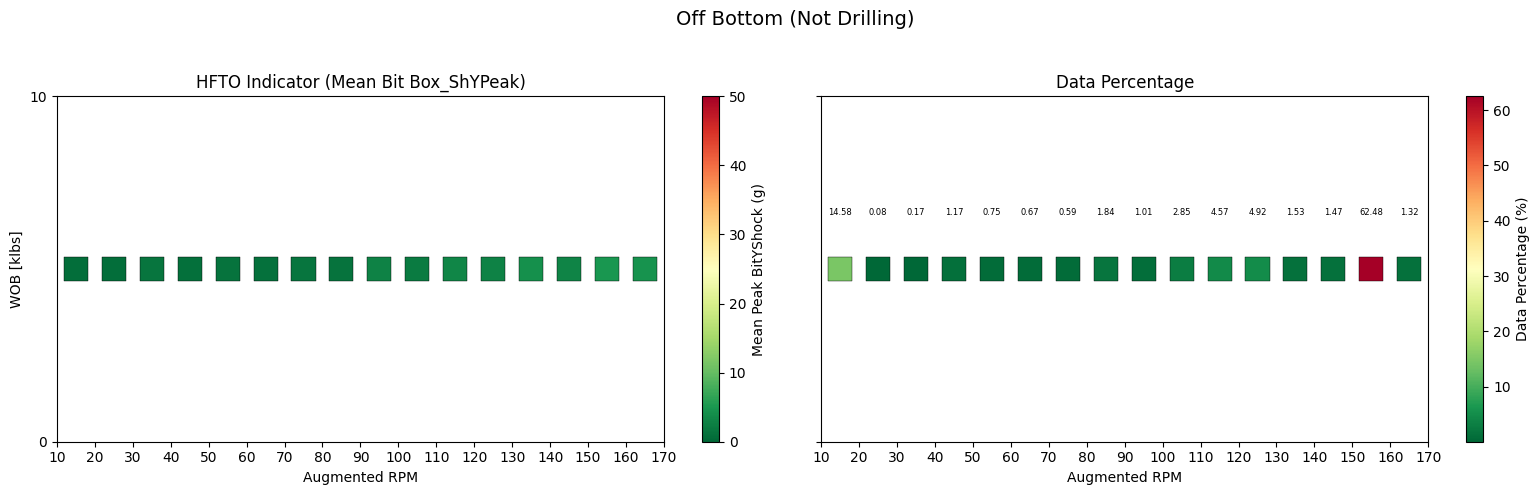

In [30]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Off Bottom (Not Drilling)": dataNotDrilling
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = torsionalCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
#maxwob_raw = max(df[wob_col].max() for df in states.values())
maxwob_raw = 10

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShYPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitYShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

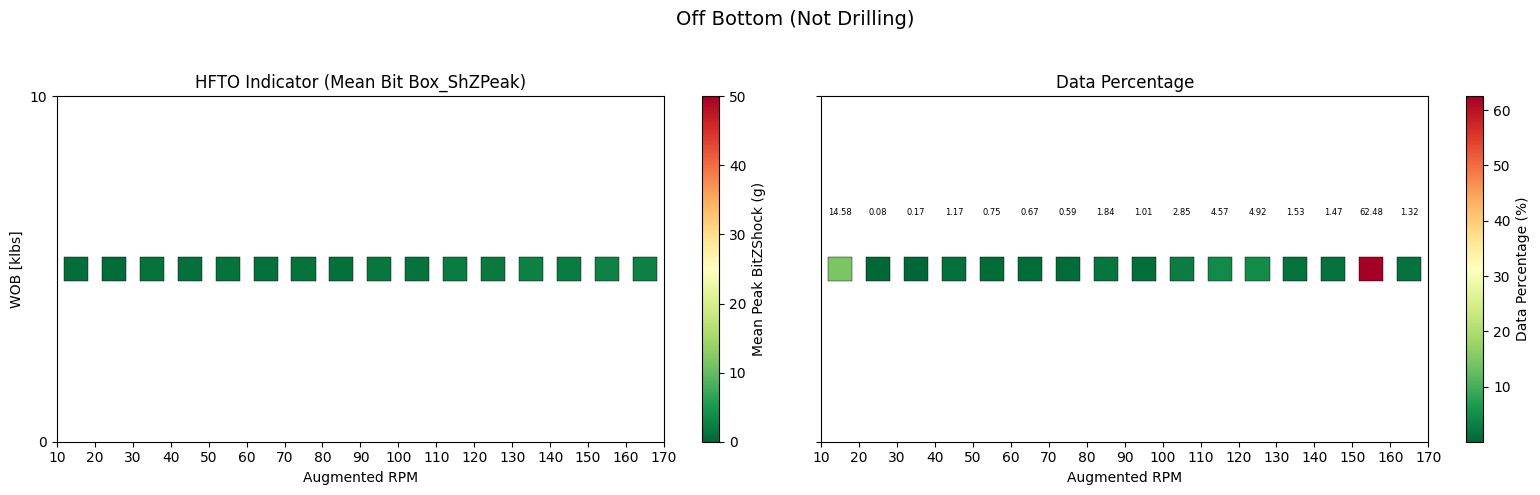

In [31]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Off Bottom (Not Drilling)": dataNotDrilling
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = lateralCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
#maxwob_raw = max(df[wob_col].max() for df in states.values())
maxwob_raw = 10

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShZPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitZShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)

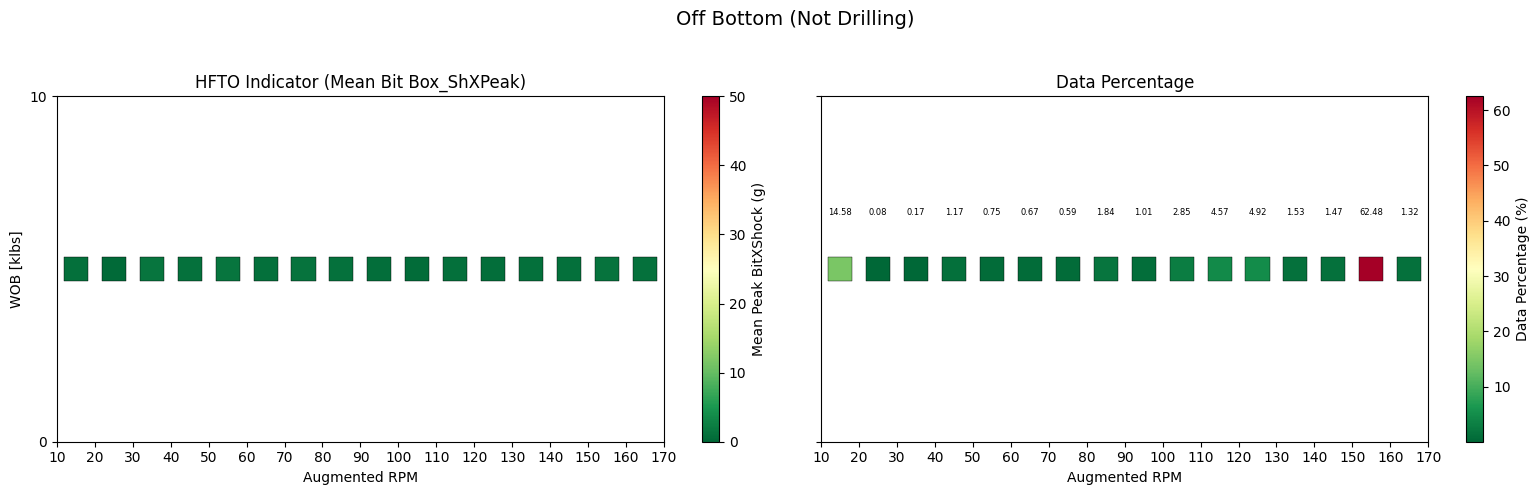

In [32]:
# ------------------------------------------------------------
# Operating states
# ------------------------------------------------------------
states = {
    "Off Bottom (Not Drilling)": dataNotDrilling
}
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
nwob = 10
nrpm = 10

wob_col = "Surface_Weight on Bit(klbs)"
rpm_col = "Augmented RPM(RPM)"
hfto_col = axialCol

# ------------------------------------------------------------
# GLOBAL mins/maxes (axis starts at GLOBAL MIN, not 0)
# ------------------------------------------------------------
minrpm_raw = min(df[rpm_col].min() for df in states.values())
maxrpm_raw = max(df[rpm_col].max() for df in states.values())

minwob_raw = min(df[wob_col].min() for df in states.values())
#maxwob_raw = max(df[wob_col].max() for df in states.values())
maxwob_raw = 10

# Bin-aligned bounds
minrpm = np.floor(minrpm_raw / nrpm) * nrpm
maxrpm = np.ceil(maxrpm_raw / nrpm) * nrpm

minwob = np.floor(minwob_raw / nwob) * nwob
maxwob = np.ceil(maxwob_raw / nwob) * nwob

rpm_edges = np.arange(minrpm, maxrpm + nrpm, nrpm)
wob_edges = np.arange(minwob, maxwob + nwob, nwob)

rpm_centers = rpm_edges[:-1] + nrpm / 2
wob_centers = wob_edges[:-1] + nwob / 2
RPM, WOB = np.meshgrid(rpm_centers, wob_centers)

# ------------------------------------------------------------
# GLOBAL colorbar limits (shared across all states)
# ------------------------------------------------------------
all_hfto_vals = []
all_pct_vals = []

for df in states.values():
    n_total = len(df)

    for wob_lo, wob_hi in zip(wob_edges[:-1], wob_edges[1:]):
        for rpm_lo, rpm_hi in zip(rpm_edges[:-1], rpm_edges[1:]):
            mask = (
                (df[wob_col] >= wob_lo) & (df[wob_col] < wob_hi) &
                (df[rpm_col] >= rpm_lo) & (df[rpm_col] < rpm_hi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                all_hfto_vals.append(vals.mean())
                all_pct_vals.append((len(vals) / n_total) * 100)

hfto_vmin = 0
hfto_vmax = 50

pct_vmin = 0
pct_vmax = max(all_pct_vals) if len(all_pct_vals) else np.nan



def plot_state(df, state_name):
    hfto = np.full((len(wob_centers), len(rpm_centers)), np.nan)
    pct  = np.full_like(hfto, np.nan)

    n_total = len(df)

    for yi, (wlo, whi) in enumerate(zip(wob_edges[:-1], wob_edges[1:])):
        for xi, (rlo, rhi) in enumerate(zip(rpm_edges[:-1], rpm_edges[1:])):
            mask = (
                (df[wob_col] >= wlo) & (df[wob_col] < whi) &
                (df[rpm_col] >= rlo) & (df[rpm_col] < rhi)
            )

            vals = df.loc[mask, hfto_col].dropna()
            if len(vals) > 0:
                hfto[yi, xi] = vals.mean()
                pct[yi, xi] = (len(vals) / n_total) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)
    fig.suptitle(state_name, fontsize=14)

    sc1 = axes[0].scatter(
        RPM.flatten(), WOB.flatten(),
        c=hfto.flatten(),
        cmap="RdYlGn_r",
        vmin=hfto_vmin, vmax=hfto_vmax,
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    sc2 = axes[1].scatter(
        RPM.flatten(), WOB.flatten(),
        c=pct.flatten(),
        cmap="RdYlGn_r",
        s=300, marker="s",
        edgecolor="k", linewidth=0.3
    )

    axes[0].set_title("HFTO Indicator (Mean Bit Box_ShXPeak)")
    axes[1].set_title("Data Percentage")

    axes[0].set_xlabel("Augmented RPM")
    axes[0].set_ylabel("WOB [klbs]")
    axes[1].set_xlabel("Augmented RPM")

    plt.colorbar(sc1, ax=axes[0], label="Mean Peak BitXShock (g)")
    plt.colorbar(sc2, ax=axes[1], label="Data Percentage (%)")

    # ---- LOCK TICKS TO BIN EDGES ----
    for ax in axes:
        ax.set_xlim(rpm_edges[0], rpm_edges[-1])
        ax.set_ylim(wob_edges[0], wob_edges[-1])
        ax.set_xticks(rpm_edges)
        ax.set_yticks(wob_edges)

    # Percentage labels
    for x, y, val in zip(RPM.flatten(), WOB.flatten(), pct.flatten()):
        if np.isfinite(val):
            axes[1].text(
                x,
                y + 0.15 * nwob,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# -----------------------------
# Run for each operating state
# -----------------------------
for name, df in states.items():
    plot_state(df, name)